## Exploratory Data Analysis - Coral Bleaching (Galápagos Islands)
**Dataset:** NOAA Coral Reef Watch, 1985-2025

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# LOAD THE DATA
file_path = '../data/galapagos_islands.csv'
data = pd.read_csv(file_path)

required_columns = [
    'Date', 'Latitude', 'Longitude',
    'Sea_Surface_Temperature', 'HotSpots',
    'Degree_Heating_Weeks', 'Bleaching_Alert_Area'
]

for col in required_columns:
    if col not in data.columns:
        raise ValueError(f"Missing column: {col}")
    
    
print("Data preview:\n", data.head(), "\n")

Data preview:
      Date  Latitude  Longitude  Sea_Surface_Temperature  HotSpots  \
0  1/1/85      0.15    -90.625                    23.83       0.0   
1  1/2/85      0.15    -90.625                    23.90       0.0   
2  1/3/85      0.15    -90.625                    23.94       0.0   
3  1/4/85      0.15    -90.625                    23.45       0.0   
4  1/5/85      0.15    -90.625                    23.62       0.0   

   Degree_Heating_Weeks  Bleaching_Alert_Area  
0                   0.0                     0  
1                   0.0                     0  
2                   0.0                     0  
3                   0.0                     0  
4                   0.0                     0   



In [17]:
# DATASET OVERVIEW
print("Dataset shape:", data.shape, "\n")
print("Data types:\n", data.dtypes, "\n")
print("Missing values:\n", data.isnull().sum(), "\n")

Dataset shape: (14661, 7) 

Data types:
 Date                           str
Latitude                   float64
Longitude                  float64
Sea_Surface_Temperature    float64
HotSpots                   float64
Degree_Heating_Weeks       float64
Bleaching_Alert_Area         int64
dtype: object 

Missing values:
 Date                       0
Latitude                   0
Longitude                  0
Sea_Surface_Temperature    0
HotSpots                   0
Degree_Heating_Weeks       0
Bleaching_Alert_Area       0
dtype: int64 



In [5]:
# SUMMARY STATISTICS
print("Summary statistics:\n", data.describe(), "\n")

Summary statistics:
            Latitude  Longitude  Sea_Surface_Temperature      HotSpots  \
count  1.466100e+04  14661.000             14661.000000  14661.000000   
mean   1.500000e-01    -90.625                24.709651      0.262910   
std    2.775652e-17      0.000                 1.912572      0.615262   
min    1.500000e-01    -90.625                19.160000      0.000000   
25%    1.500000e-01    -90.625                23.280000      0.000000   
50%    1.500000e-01    -90.625                24.510000      0.000000   
75%    1.500000e-01    -90.625                26.140000      0.000000   
max    1.500000e-01    -90.625                30.470000      4.320000   

       Degree_Heating_Weeks  Bleaching_Alert_Area  
count          14661.000000          14661.000000  
mean               2.489426              0.625128  
std                5.414412              1.187179  
min                0.000000              0.000000  
25%                0.000000              0.000000  
50%      

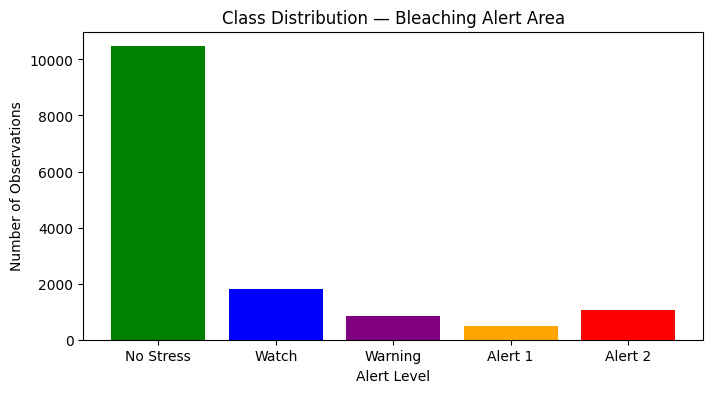

In [28]:
# CLASS DISTRIBUTION
class_counts = data['Bleaching_Alert_Area'].value_counts().sort_index()
class_labels = ['No Stress', 'Watch', 'Warning', 'Alert 1', 'Alert 2']

plt.figure(figsize=(8, 4))
plt.bar(class_labels, class_counts, color=['green', 'blue', 'purple', 'orange', 'red'])
plt.title("Class Distribution — Bleaching Alert Area")
plt.xlabel("Alert Level")
plt.ylabel("Number of Observations")
plt.show()


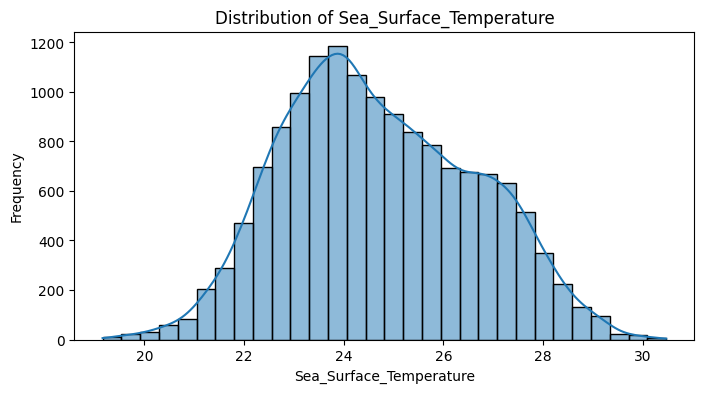

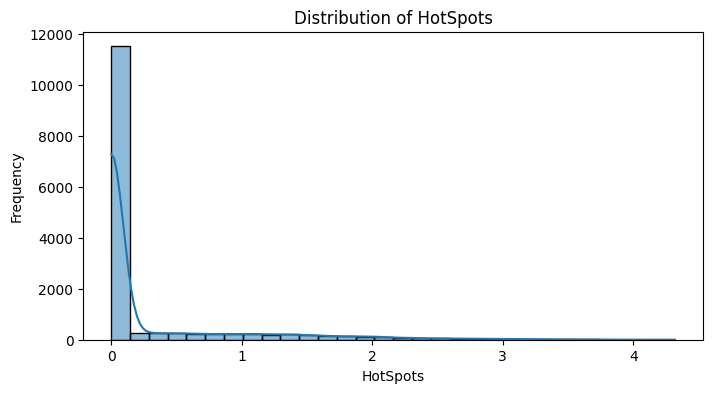

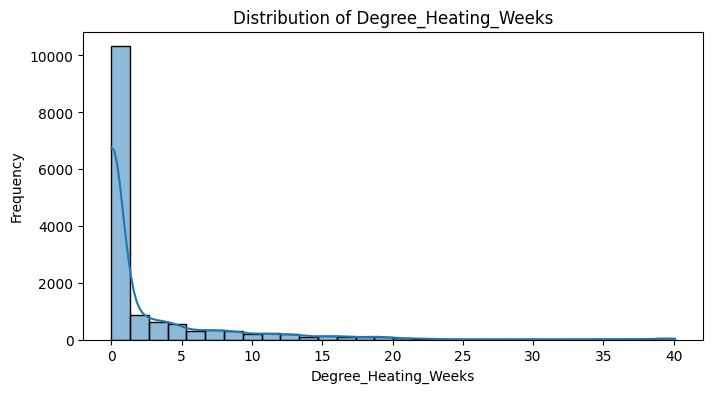

In [7]:
# FEATURE DISTRIBUTIONS
features = ['Sea_Surface_Temperature', 'HotSpots', 'Degree_Heating_Weeks']
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

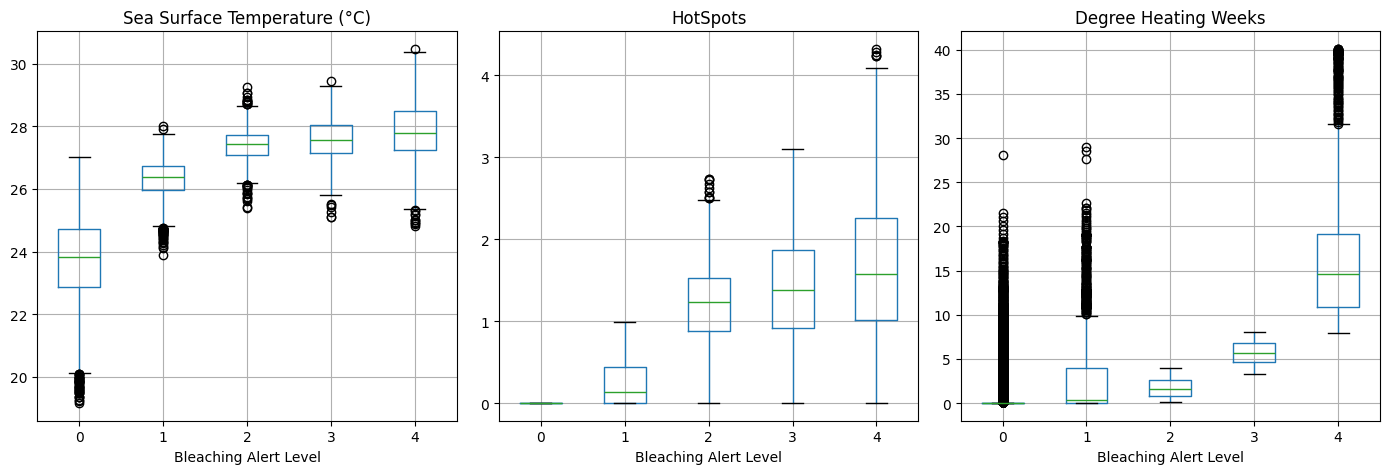

In [42]:
# FEATURE DISTRIBUTIONS BY CLASS
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

features = ['Sea_Surface_Temperature', 'HotSpots', 'Degree_Heating_Weeks']
titles = ['Sea Surface Temperature (°C)', 'HotSpots', 'Degree Heating Weeks']

for ax, feature, title in zip(axes, features, titles):
    data.boxplot(column=feature, by='Bleaching_Alert_Area', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Bleaching Alert Level')
    ax.set_ylabel('')

plt.suptitle('Feature Distributions by Bleaching Alert Level')
fig.suptitle('')
plt.tight_layout()
plt.show()


<Axes: >

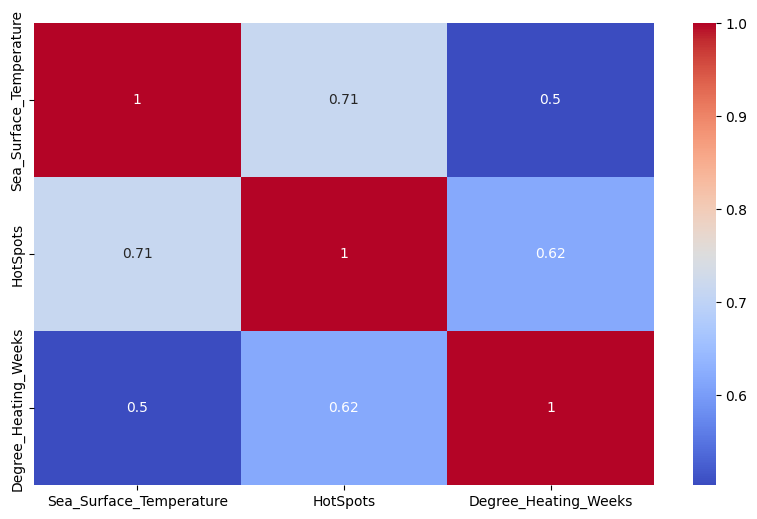

In [40]:
# CORRELATION HEATMAP
plt.figure(figsize=(10, 6))
sns.heatmap(data[['Sea_Surface_Temperature', 'HotSpots', 'Degree_Heating_Weeks']].corr(), annot=True, cmap='coolwarm')

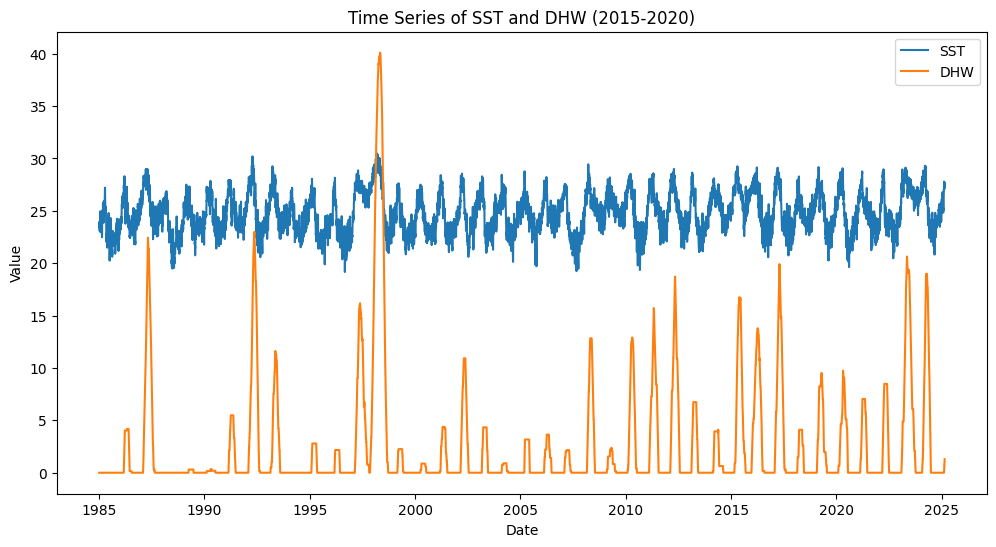

In [23]:
# TIME SERIES ANALYSIS: SST AND DHW FROM 2015 TO 2020
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
#time_series_data = data[(data['Date'] >= '2015-01-01') & (data['Date'] <= '2020-12-31')]
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Sea_Surface_Temperature', data=data, label='SST')
sns.lineplot(x='Date', y='Degree_Heating_Weeks', data=data, label='DHW')
plt.title("Time Series of SST and DHW (2015-2020)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

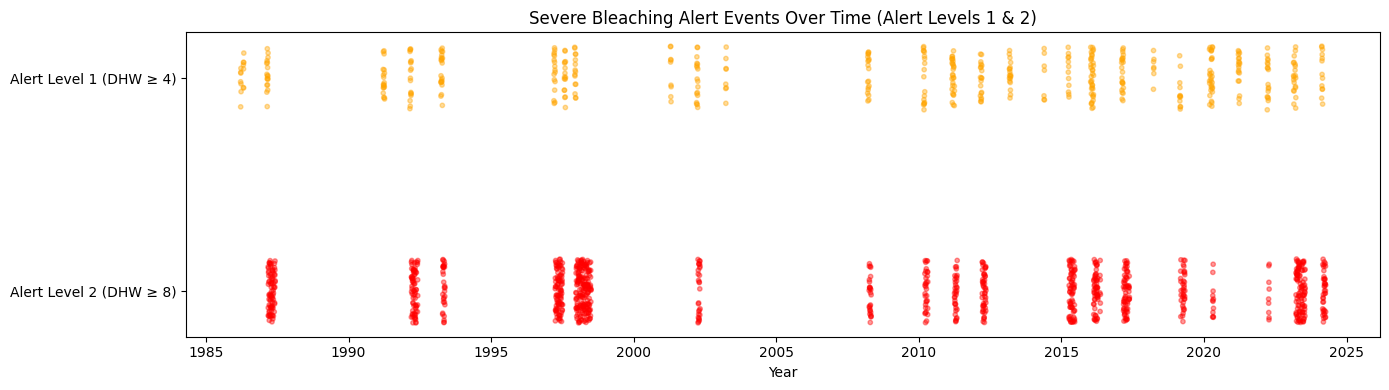

In [37]:
# 11. BLEACHING ALERT EVENTS OVER TIME
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%y')

alert_events = data[data['Bleaching_Alert_Area'] >= 3]

plt.figure(figsize=(14, 4))
jitter = np.random.uniform(-0.15, 0.15, size=len(alert_events))
plt.scatter(
    alert_events['Date'],
    -alert_events['Bleaching_Alert_Area'] + jitter,
    c=alert_events['Bleaching_Alert_Area'].map({3: 'orange', 4: 'red'}),
    alpha=0.4,
    s=10
)
plt.yticks([-3, -4], ['Alert Level 1 (DHW ≥ 4)', 'Alert Level 2 (DHW ≥ 8)'])
plt.xlabel("Year")
plt.title("Severe Bleaching Alert Events Over Time (Alert Levels 1 & 2)")
plt.tight_layout()
plt.show()

